In [107]:
# %pip install torch_geometric
# %pip install ogb
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [108]:
import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

In [109]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull



def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [110]:
# from torch_geometric.datasets import LINKXDataset
# dataset_name = 'Roman-empire'
# dataset = HeterophilousGraphDataset('/tmp/Cora', DATASET_NAME)
# DATASET_NAME = dataset_name
# data = dataset[0]
# print(data)

In [111]:
from torch_geometric.datasets import KarateClub, Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset,LINKXDataset

def load_dataset(dataset_name):
    if dataset_name == "karate":
        dataset = KarateClub()
    elif dataset_name == "moon":
        from ipynb.fs.full.Moon import MoonDataset
        dataset = MoonDataset(n_samples=50, degree=5, train=0.4, h = 0.5)
    elif dataset_name == "SmallCora":
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')
    elif dataset_name in ["Cora", "Cora_ML" "CiteSeer", "DBLP", "PubMed"]:
        dataset = CitationFull(root=DIR+'/tmp/Citation/'+dataset_name, name=dataset_name)
    elif dataset_name == 'Amazon-ratings':
        dataset = HeterophilousGraphDataset(root=DIR+'/tmp/amazon_ratings', name = dataset_name)
    elif dataset_name == 'Roman-empire':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(DIR+'/tmp/Roman_empire', dataset_name)
    elif dataset_name == "Reddit":
        dataset = Reddit(root=DIR+'/tmp/Reddit')
    elif dataset_name == 'penn94':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(root=DIR+'/tmp/LINKX', name=dataset_name)
    elif dataset_name == 'wiki':
        from torch_geometric.datasets import WikiCS
        dataset = WikiCS(root=DIR+'/tmp/WikiCS')
    elif dataset_name == 'Photo':
        dataset = Amazon(root=DIR+'/tmp/Photo', name='Photo')
    elif dataset_name == 'CiteSeer':
        dataset = Planetoid(root=DIR+'/tmp/CiteSeer', name=DATASET_NAME)
    elif dataset_name == 'CS':
        dataset = Coauthor(root=DIR+'/tmp/CS', name = DATASET_NAME)
    elif dataset_name == 'Physics':
        dataset = Coauthor(root=DIR+'/tmp/Physics', name = DATASET_NAME)
    elif dataset_name == 'Minesweeper':
        dataset   = HeterophilousGraphDataset(root=DIR+'/tmp/Mine',name=dataset_name)
    elif dataset_name == 'pokec':
        print("HELLOWROLD ")
    elif dataset_name == 'ogbn-proteins':
        dataset = PygNodePropPredDataset(name='ogbn-proteins', root=DIR+'/tmp/ogbn-proteins')
        data = dataset[0]
        data.node_species = None
        data.y = data.y.to(torch.float)

        # Initialize features of nodes by aggregating edge features.
        row, col = data.edge_index
        data.x = scatter(data.edge_attr, col, dim_size=data.num_nodes, reduce='sum')
        labels = data.y.argmax(dim=1)
        data.y = labels
        return dataset, data
    elif dataset_name == 'squirrel':
        dataset = WikipediaNetwork(root=DIR+'/tmp/squirrel', name='Squirrel')
    elif dataset_name == 'AmazonProducts':
        dataset = AmazonProducts(root=DIR+'/tmp/AmazonProducts')
    else:
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')

    print(dataset)
    data = dataset[0]
    print(data)
    return dataset, data

# Example usage:
dataset_name = "moon"
DATASET_NAME = dataset_name
dataset, data = load_dataset(dataset_name)

MoonDataset(10)
Data(x=[50, 2], edge_index=[2, 404], y=[50], train_mask=[50], val_mask=[50], test_mask=[50], edge_weight=[404, 1])


In [112]:
# dataset_name = 'Roman-empire'
# DATASET_NAME = dataset_name
# dataset   = HeterophilousGraphDataset(root='/tmp/roman',name=dataset_name)
# data = dataset[0]
# print(data)

In [113]:
dataset.num_classes

2

In [114]:
def train_val_test_mask(data, train=0.4, val=0.3, test=0.3, random_state=False):

    if isinstance(data.x, SparseTensor):
        N = data.x.size(0)
        data.num_nodes = N
    else:
        N = data.x.shape[0]

    indexs = list(range(N))

    if random_state:
        train_index, test_index = train_test_split(indexs, test_size=val+test)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test))
    else:
        train_index, test_index = train_test_split(indexs, test_size=val+test, random_state=1)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test), random_state=1)



    train_mask = torch.zeros(N, dtype=bool)
    train_mask[train_index]=True
    val_mask = torch.zeros(N, dtype=bool)
    val_mask[val_index]=True
    test_mask = torch.zeros(N, dtype=bool)
    test_mask[test_index]=True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

In [115]:
if hasattr(data, 'train_mask') == False:
    data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)

if len(data.train_mask.shape) > 1:
    split_index = 2
    data.train_mask = data.train_mask[:,split_index]
    data.val_mask = data.val_mask[:,split_index]
    data.test_mask = data.test_mask[:,split_index]

data = train_val_test_mask(data, train=0.6, val=0.2, test=0.2)
data

Data(x=[50, 2], edge_index=[2, 404], y=[50], train_mask=[50], val_mask=[50], test_mask=[50], edge_weight=[404, 1])

In [116]:
# Define the MLP for edge probability
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super(EdgeProbMLP, self).__init__()
        self.fc1 = nn.Linear(2 * in_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):
        edge_features = torch.cat([node_features[edge_index[0]], node_features[edge_index[1]]], dim=1)
        x = F.relu(self.fc1(edge_features))
        prob = torch.sigmoid(self.fc2(x))
        return prob

# Define the overall model with Edge Probabilities and GCNConv (GNN)
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index):
        x = F.relu(self.gcn1(data.x, edge_index))
        out = self.gcn2(x, edge_index)
        return out

# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(edge_probs, edge_index, q=500):
    gumbels = -torch.empty_like(edge_probs).exponential_().log()
    logits = (edge_probs + gumbels) / 0.5
    samples = F.softmax(logits, dim=-1)
    sampled_edges = torch.multinomial(samples, q, replacement=False)
    return sampled_edges

# Random edge sampling
def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function with alternating updates
def train(model, optimizer_gnn, optimizer_edge_prob, criterion, cluster_loader, device, q=500, mode='learned', alternate_frequency=1):
    model.train()
    total_loss = 0
    iteration = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        
        if alternate_frequency == 0:
            update_gnn = True
            update_edge_prob = True
        else:
            
            # Decide if we are updating GNN or edge probability model
            update_gnn = iteration % alternate_frequency == 0
            update_edge_prob = not update_gnn

        # Zero gradients selectively
        if update_gnn:
            optimizer_gnn.zero_grad()
        if update_edge_prob:
            optimizer_edge_prob.zero_grad()

        # Select edges based on mode
        if mode == 'learned':
            if batch.edge_index.shape[1] > q:
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()
                sampled_edge_indices = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q)
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
        elif mode == 'random':
            if batch.edge_index.shape[1] > q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
        elif mode == 'full':
            out = model(batch, batch.edge_index)
        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

        # Compute node classification loss
        loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
        loss.backward()

        # Update parameters selectively
        if update_gnn:
            optimizer_gnn.step()
        if update_edge_prob:
            optimizer_edge_prob.step()

        total_loss += loss.item()
        iteration += 1

    return total_loss / len(cluster_loader)

# Evaluation function remains unchanged
def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            if mode == 'learned':
                if batch.edge_index.shape[1] > q:
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()
                    sampled_edge_indices = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'random':
                if batch.edge_index.shape[1] > q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'full':
                out = model(batch, batch.edge_index)
            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

Main for multiple runs

In [117]:
data

Data(x=[50, 2], edge_index=[2, 404], y=[50], train_mask=[50], val_mask=[50], test_mask=[50], edge_weight=[404, 1])

In [118]:
# Training configuration
RUNS = 1
NUM_EPOCHS = 2000
best_test_f1s = []
log = True
mode = 'learned'  # available modes ['learned', 'random', 'full']
alternate_frequency = 0  # Frequency of alternation between updating GNN and EdgeProb models
sample_percent = 0.20

# Check node count to decide if partitioning is necessary
use_metis = data.num_nodes >= 10000

if use_metis:
    num_parts = 2
    num_edges_per_partition = int(data.edge_index.shape[1] / num_parts)
    sample_size = int(num_edges_per_partition * sample_percent)
    print("Using METIS with num_parts:", num_parts, "avg edges per partition:", num_edges_per_partition, "sample size:", sample_size)
else:
    print("Graph has fewer than 10,000 nodes; don't do graph partition")
    sample_size = int(data.edge_index.shape[1]* sample_percent)

# Partition data using METIS clustering or use the entire graph
if use_metis:
    start = time.time()
    cluster_dir = DIR + 'tmp/' + DATASET_NAME
    if not os.path.exists(cluster_dir):
        os.makedirs(cluster_dir)

    cluster_data = ClusterData(data, num_parts=num_parts, recursive=False, save_dir=cluster_dir, log=True)
    print("METIS Partition time:", time.time() - start)
    cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)
else:
    # Load the entire graph as a single batch if partitioning is not needed
    cluster_loader = [data]  # Using a list to match the expected iterable interface

# Training and evaluation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for run in range(RUNS):
    print("Run:", run)

    # Initialize model and optimizers
    model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
    optimizer_gnn = torch.optim.Adam([param for name, param in model.named_parameters() if 'gcn' in name], lr=0.01)
    optimizer_edge_prob = torch.optim.Adam([param for name, param in model.named_parameters() if 'edge_prob_mlp' in name], lr=0.01)
    criterion = nn.CrossEntropyLoss()

    # Initialize F1 score trackers
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)
    best_test_f1 = 0

    # Training over epochs
    for epoch in range(NUM_EPOCHS):
        # Alternate training of GNN and edge probability model based on frequency
        loss = train(
            model,
            optimizer_gnn,
            optimizer_edge_prob,
            criterion,
            cluster_loader,
            device,
            q=sample_size,
            mode=mode,
            alternate_frequency = alternate_frequency
        )

        # Evaluate model performance on train, validation, and test sets
        train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)

        # Store F1 scores
        train_f1_scores[epoch] = train_f1
        val_f1_scores[epoch] = val_f1
        test_f1_scores[epoch] = test_f1

        # Update best test F1 score
        if test_f1 > best_test_f1:
            best_test_f1 = test_f1
            

        if log:
            if epoch%100 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

    # Print best test F1 score for this run
    print(f'Best Test F1 Score: {best_test_f1:.4f}')
    best_test_f1s.append(best_test_f1)

# Report the mean and standard deviation of the best test F1 scores over runs
print(f'Mean Std of Test F1 Score: {np.mean(best_test_f1s):.4f} +/- {np.std(best_test_f1s):.4f}')


Graph has fewer than 10,000 nodes; don't do graph partition
Run: 0
Epoch 0, Loss: 0.7987, Train F1: 0.7333, Val F1: 0.6000, Test F1: 0.4000
Epoch 100, Loss: 0.6044, Train F1: 0.7000, Val F1: 0.6000, Test F1: 0.3000
Epoch 200, Loss: 0.5317, Train F1: 0.6333, Val F1: 0.5000, Test F1: 0.4000
Epoch 300, Loss: 0.4625, Train F1: 0.6667, Val F1: 0.7000, Test F1: 0.8000
Epoch 400, Loss: 0.6463, Train F1: 0.6667, Val F1: 0.5000, Test F1: 0.4000
Epoch 500, Loss: 0.6203, Train F1: 0.6000, Val F1: 0.8000, Test F1: 0.7000
Epoch 600, Loss: 0.5705, Train F1: 0.6000, Val F1: 0.6000, Test F1: 0.5000
Epoch 700, Loss: 0.6739, Train F1: 0.7333, Val F1: 0.6000, Test F1: 0.5000
Epoch 800, Loss: 0.6364, Train F1: 0.7333, Val F1: 0.5000, Test F1: 0.4000
Epoch 900, Loss: 0.6523, Train F1: 0.6000, Val F1: 0.8000, Test F1: 0.5000
Epoch 1000, Loss: 0.5359, Train F1: 0.7000, Val F1: 0.5000, Test F1: 0.4000
Epoch 1100, Loss: 0.5837, Train F1: 0.7000, Val F1: 0.5000, Test F1: 0.3000
Epoch 1200, Loss: 0.4796, Train F

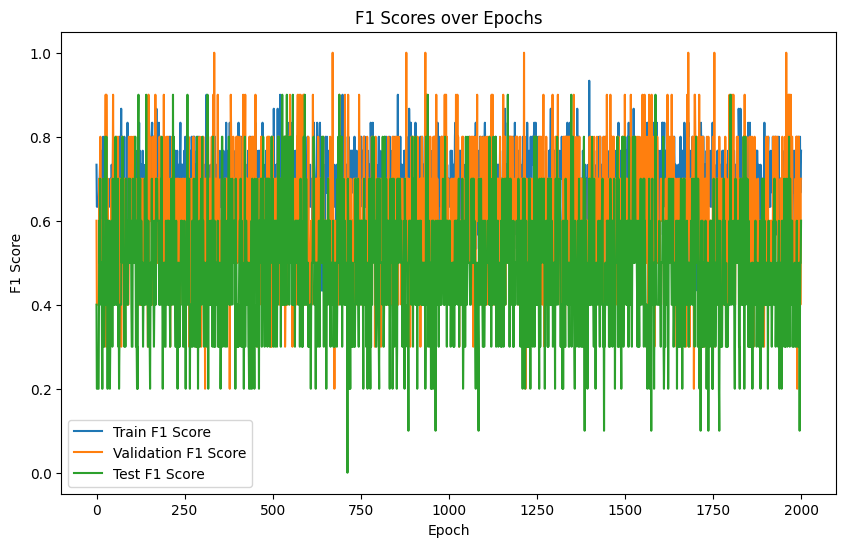

In [119]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [120]:
for batch in cluster_loader:
    print(batch.num_nodes)
    print(batch.edge_index.shape)

50
torch.Size([2, 404])


In [121]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

In [122]:
torch.where(data.train_mask == True)

(tensor([ 0,  1,  4,  5,  6,  7,  8,  9, 10, 11, 12, 14, 15, 16, 17, 18, 20, 23,
         24, 25, 28, 30, 33, 34, 37, 41, 43, 44, 45, 47], device='cuda:0'),)

In [123]:
def count_edges_with_different_labels(data, sampled_edge_index):
    """
    Counts edges with different labels at endpoints in both the original and sampled graphs.
    
    Args:
        data: Data object containing the original graph information.
        sampled_edge_index: Edge index of the sampled subgraph.
    
    Returns:
        A dictionary with counts and percentages of edges with different labels.
    """
    # Original graph edges
    original_edges = data.edge_index
    num_original_edges = original_edges.size(1)
    
    # Count edges with different labels in the original graph
    different_label_edges_original = 0
    for i in range(num_original_edges):
        node1, node2 = original_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_original += 1
    
    # Sampled graph edges
    sampled_edges = sampled_edge_index
    num_sampled_edges = sampled_edges.size(1)

    # Count edges with different labels in the sampled graph
    different_label_edges_sampled = 0
    for i in range(num_sampled_edges):
        node1, node2 = sampled_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_sampled += 1

    # Calculate percentages
    percentage_original = (different_label_edges_original / num_original_edges) * 100 if num_original_edges > 0 else 0
    percentage_sampled = (different_label_edges_sampled / num_sampled_edges) * 100 if num_sampled_edges > 0 else 0

    # Prepare the result
    result = {
        "original_graph": {
            "different_label_edges": different_label_edges_original,
            "total_edges": num_original_edges,
            "percentage": percentage_original
        },
        "sampled_graph": {
            "different_label_edges": different_label_edges_sampled,
            "total_edges": num_sampled_edges,
            "percentage": percentage_sampled
        }
    }

    return result

In [124]:
def plot_full_graph_with_train_nodes(data, train_mask, ax=None):
    """
    Plots the full graph with training nodes highlighted and colored by their labels.
    Args:
        data: Data object containing edge_index, node labels, and other features.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert PyG data to NetworkX graph for visualization
    G = to_networkx(data)
    
    # Generate color map for each label
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Set node colors based on whether they are a training node and their label
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() else 'gray' for i in range(data.num_nodes)
    ]

    # Define node positions for consistent layout
    pos = nx.spring_layout(G, seed=42)

    # Plot the full graph with training nodes highlighted by label color
    nx.draw(G, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="lightblue")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Full Graph with Training Nodes Highlighted by Label")
    ax.axis("off")
    
    return pos


def plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=None, pos=None):
    """
    Plots the sampled subgraph based on the edge probability model with training nodes highlighted by label.
    Args:
        data: Data object containing node information.
        sampled_edge_index: Edge index of the sampled subgraph.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert sampled edges to NetworkX graph
    G_sampled = to_networkx(Data(x = data.x, y = data.y, edge_index = sampled_edge_index))
    
    # Use same color map as the full graph
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Use same layout as the full graph for consistent positioning
    if pos is None:
        pos = nx.spring_layout(G_sampled, seed=42)
    
    # Set node colors based on training status and label for nodes in the sampled graph
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() and i in G_sampled.nodes else 'gray'
        for i in G_sampled.nodes
    ]

    # Plot the sampled subgraph with node labels
    nx.draw(G_sampled, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="orange")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Sampled Subgraph (Edge Probability Model) with Training Nodes Highlighted by Label")
    ax.axis("off")


def visualize_graphs_side_by_side(data, train_mask, sampled_edge_index):
    """
    Visualizes the full graph with training nodes and the sampled subgraph side by side, with training nodes colored by label.
    Args:
        data: Data object containing the full graph information.
        train_mask: Boolean tensor indicating training nodes.
        sampled_edge_index: Edge index of the sampled subgraph.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot full graph with training nodes highlighted by label
    pos1 = plot_full_graph_with_train_nodes(data, train_mask, ax=ax1)

    # Plot sampled subgraph with training nodes highlighted by label, using the same layout
    plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=ax2, pos=pos1)

    plt.show()

# Example Usage:
# Assuming `train_mask` is a boolean mask tensor, and `sampled_edge_index` is the edge index after sampling
# visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index)

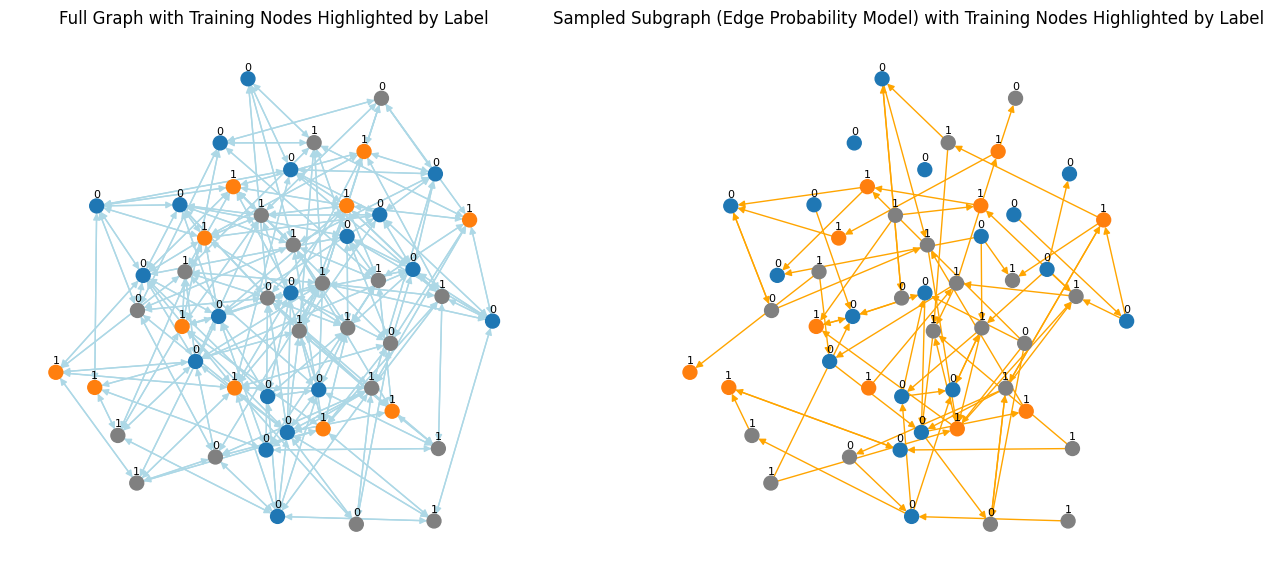

Original graph: 180 edges with different labels out of 404 total edges (44.55%).
Sampled graph: 34 edges with different labels out of 80 total edges (42.50%).


In [126]:
with torch.no_grad():
    edge_probs = model.edge_prob_mlp(data.x, data.edge_index).squeeze()
    sampled_edge_indices = gumbel_softmax_sampling(edge_probs, data.edge_index, q=sample_size)
    sampled_edge_index = data.edge_index[:, sampled_edge_indices]
    visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index)

    # Example Usage
    # Assuming `data` is your original graph and `sampled_edge_index` is your sampled edge index
    result = count_edges_with_different_labels(data, sampled_edge_index)

    # Print the results
    print(f"Original graph: {result['original_graph']['different_label_edges']} edges with different labels "
          f"out of {result['original_graph']['total_edges']} total edges "
          f"({result['original_graph']['percentage']:.2f}%).")

    print(f"Sampled graph: {result['sampled_graph']['different_label_edges']} edges with different labels "
          f"out of {result['sampled_graph']['total_edges']} total edges "
          f"({result['sampled_graph']['percentage']:.2f}%).")